# SHISMA WORKFLOW WITH TOY DATASET
This is an unpacked version of shisma package to showcase the workflow and the core elements. \
DISCLAIMER #1: The toy dataset we employed here, is a random subset of just 5K observations. No relevant biological information can be inferred from this. \
DISCLAIMER #2: Since no subnets pass the cell specificity filter, we show the significant but unfiltered gene groups. Obviously, these plots do not make much sense.

## Load packages

In [ ]:
import numpy as np
import pandas as pd
import fasttreeshap
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from fast_borf import BorfBuilder
from fast_borf.pipeline.zero_columns_remover import ZeroColumnsRemover
from fast_borf.pipeline.reshaper import ReshapeTo2D
from fast_borf.pipeline.to_scipy import ToScipySparse
from fast_borf.xai.mapping import BagOfReceptiveFields
from toy_example_config import CUSTOM_CONFIG_A3_NO_DILATION_WINDOW_SIZE_2_3_4
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

## Load dataset

In [14]:
def load_real_dataset(filepath, target_ct="Bcells"):
    print(f"Loading real dataset from {filepath}...")
    
    df_real = pd.read_csv(filepath, index_col=0)

    df_real.columns = [f"T{i}" for i in range(len(df_real.columns))]
    
    df_real = df_real.fillna(0.0)
    
    print(f"  -> Loaded {df_real.shape[0]} samples across {df_real.shape[1]} timepoints.")
    print(f"  -> Target cell type set to: {target_ct}")
    
    return df_real, target_ct

def generate_shisma_data(n_genes=200, n_planted=20, n_timepoints=6, n_pats=5, n_celltypes=10):
    np.random.seed(42)
    
    cell_types = np.array([f"CT{i}" for i in range(n_celltypes)])
    target_ct = "CT0"
    padding = len(str(n_genes - 1))
    genes = np.array([f"G{i:0{padding}d}" for i in range(n_genes)])
    planted_genes = genes[:n_planted]
    
    edges = [[planted_genes[i], planted_genes[j]] for i in range(n_planted) for j in range(i+1, n_planted)]
    for _ in range(n_genes * 2): 
        g1, g2 = np.random.choice(genes, 2)
        if g1 != g2: edges.append([g1, g2])
    ppi_df = pd.DataFrame(edges, columns=["gene1", "gene2"]).drop_duplicates()

    print("Generating realistic Negative Binomial gene expression...")
    n_samples = n_genes * n_celltypes * n_pats
    
    mesh_genes, mesh_cts, mesh_pats = np.meshgrid(np.arange(n_genes), np.arange(n_celltypes), np.arange(n_pats), indexing='ij')
    flat_gene_idx = mesh_genes.flatten()
    flat_ct_idx = mesh_cts.flatten()
    flat_pats = mesh_pats.flatten()
    
    gene_baselines = np.random.gamma(shape=2.0, scale=1.5, size=n_genes)
    
    ct_multipliers = np.random.lognormal(mean=0.0, sigma=0.5, size=(n_genes, n_celltypes))
    
    base_means = gene_baselines[flat_gene_idx] * ct_multipliers[flat_gene_idx, flat_ct_idx]
    
    mu_matrix = np.tile(base_means[:, np.newaxis], (1, n_timepoints))
    biological_noise = np.random.lognormal(mean=0.0, sigma=0.1, size=(n_samples, n_timepoints))
    mu_matrix = mu_matrix * biological_noise
    
    raw_counts = np.random.poisson(lam=mu_matrix)
    
    dropout_probs = np.exp(-0.1 * mu_matrix)
    dropouts = np.random.binomial(n=1, p=dropout_probs)
    raw_counts = raw_counts * (1 - dropouts)
    
    normalized_expression = np.log1p(raw_counts)
    
    is_target_ct = (cell_types[flat_ct_idx] == target_ct)
    is_planted_gene = np.isin(genes[flat_gene_idx], planted_genes)
    plant_mask = is_target_ct & is_planted_gene
    normalized_expression[plant_mask, 3] += 2.0
    normalized_expression[plant_mask, 4] -= 1.5 
    normalized_expression[plant_mask, 5] += 2.0
    
    df_synth = pd.DataFrame(normalized_expression, columns=[f"T{t}" for t in range(n_timepoints)])
    
    flat_genes = genes[flat_gene_idx]
    flat_cts = cell_types[flat_ct_idx]
    
    df_synth.index = [f"{g}_pat{r}_{ct}" for g, ct, r in zip(flat_genes, flat_cts, flat_pats)]
    
    return df_synth, ppi_df, list(planted_genes), target_ct

In [15]:
real_data = True
correction_method = 'bonferroni'

if real_data:
    target_ct = "CD4memoryactivatedT"
    df_synth, target_ct = load_real_dataset("toy_dataset_5000.csv", target_ct=target_ct)

    ppi_synth = pd.read_csv("string_is_0.7_ev_reactome.tsv", sep="\t")
    ppi_synth = ppi_synth[['gene1', 'gene2']]
    ppi_genes = np.unique(ppi_synth[["gene1", "gene2"]].values.astype(str))
else:
    df_synth, ppi_synth, target_genes, target_ct = generate_shisma_data(
        n_genes=300, 
        n_planted=30, 
        n_timepoints=6, 
        n_pats=6,        
        n_celltypes=5
    )
df_synth.head(), df_synth.shape

Loading real dataset from toy_dataset_5000.csv...
  -> Loaded 5000 samples across 6 timepoints.
  -> Target cell type set to: CD4memoryactivatedT


(                                          T0        T1   T2        T3  \
 gene_patient_celltype                                                   
 SNX7_im_CyclingCD8memoryactivatedT  0.000000  0.000000  0.0  0.008431   
 AC003988.1_rs_CD4memoryT            0.000000  0.000000  0.0  0.000000   
 TSPAN33_sz_γδTcells                 0.003159  0.019511  0.0  0.000000   
 NFXL1_em_CD8memoryactivatedT        0.000000  0.000000  0.0  0.107010   
 AC084125.3_gz_CIKcells              0.000000  0.000000  0.0  0.000000   
 
                                           T4        T5  
 gene_patient_celltype                                   
 SNX7_im_CyclingCD8memoryactivatedT  0.000000  0.000000  
 AC003988.1_rs_CD4memoryT            0.000000  0.000000  
 TSPAN33_sz_γδTcells                 0.000000  0.000000  
 NFXL1_em_CD8memoryactivatedT        0.099128  0.106599  
 AC084125.3_gz_CIKcells              0.000000  0.000000  ,
 (5000, 6))

## Bag of Receptive Fields

In [16]:
print("1. Filtering for PPI genes & Handling Replicates...")
ppi_genes = np.unique(ppi_synth[['gene1', 'gene2']].values.astype(str))
index_dims = df_synth.index.str.rsplit('_', n=2, expand=True)
index_dims.names = ["gene", "patient", "celltype"] 
df_synth.index = index_dims
df_synth = df_synth[df_synth.index.get_level_values("gene").isin(ppi_genes)]
print(f"  -> Reduced to {len(df_synth.index.get_level_values('gene').unique())} valid PPI genes.")
df_processed = df_synth
df_target_ct = df_processed.xs(target_ct, level="celltype")
labels = np.array([target_ct] * len(df_target_ct))
genes_vec = df_target_ct.index.get_level_values("gene").values
X_raw = df_target_ct.values[:, np.newaxis, :]

print(f"\n2. Running BORF Transformation for {target_ct}...")
builder = BorfBuilder(
    n_jobs=-1, 
    configs=CUSTOM_CONFIG_A3_NO_DILATION_WINDOW_SIZE_2_3_4,
    pipeline_objects=[
        (ReshapeTo2D, dict(keep_unraveled_index=True)), 
        (ZeroColumnsRemover, dict(axis=0)), 
        (ToScipySparse, dict())
    ]
)
borf_model = builder.build(X_raw)
X_dense = borf_model.fit_transform(X_raw).toarray()
X_dense = (X_dense != 0).astype(int)
is_target_ct = (labels == target_ct)
genes_ct = genes_vec
df_X = pd.get_dummies(genes_ct, dtype=int)

print(f"BORF Matrix Shape: {X_dense.shape} (Genes x Patterns)")

1. Filtering for PPI genes & Handling Replicates...
  -> Reduced to 270 valid PPI genes.

2. Running BORF Transformation for CD4memoryactivatedT...
BORF Matrix Shape: (12, 45) (Genes x Patterns)


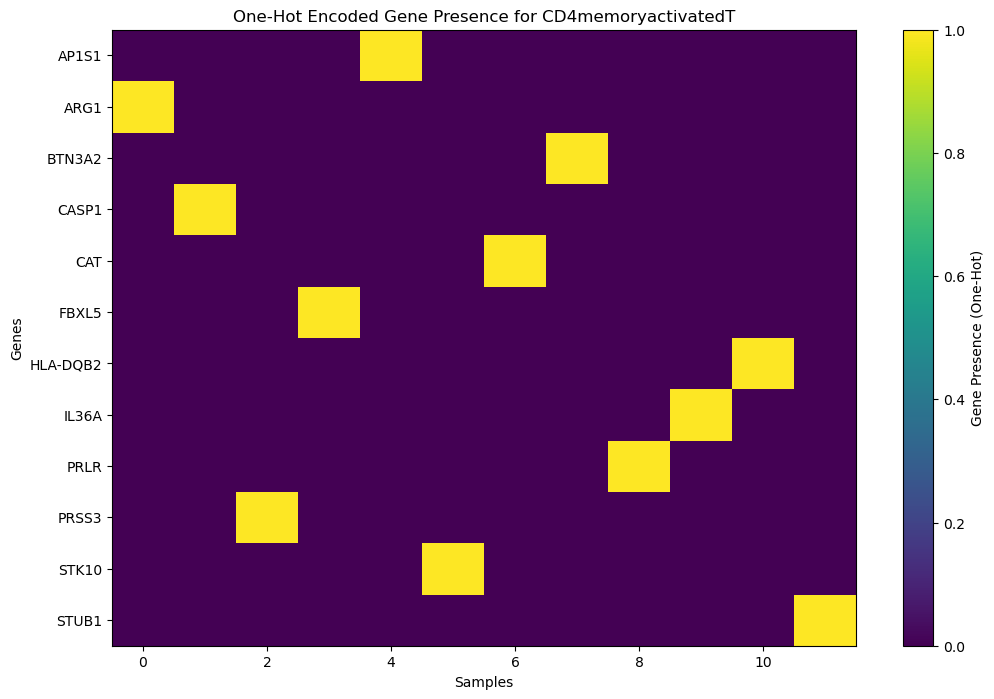

In [17]:
# heatmap df_X
plt.figure(figsize=(12, 8))
plt.imshow(df_X.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Gene Presence (One-Hot)')
plt.yticks(ticks=np.arange(len(df_X.columns)), labels=df_X.columns)
plt.title(f"One-Hot Encoded Gene Presence for {target_ct}")
plt.xlabel("Samples")
plt.ylabel("Genes")
plt.show()

## SHAP score calculation

In [ ]:
#suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="shap")

is_target_ct = (labels == target_ct)
X_dense_ct = X_dense[is_target_ct]
genes_ct = genes_vec[is_target_ct]
df_X = pd.get_dummies(genes_ct, dtype=int)

shap_df = pd.DataFrame(columns=np.arange(X_dense_ct.shape[1]), index=df_X.columns)

def process_pattern(idx, X_dense_ct_slice, df_X):
    y_counts = X_dense_ct_slice
    
    # Fit model
    model = DecisionTreeClassifier(max_depth=20, random_state=42)
    model.fit(df_X, y_counts)
    acc_score = model.score(df_X, y_counts)
    
    # Extract SHAP
    explainer = fasttreeshap.TreeExplainer(model)
    shap_values_raw = explainer.shap_values(df_X, check_additivity=False)
    
    if isinstance(shap_values_raw, list):
        shap_values_class_1 = shap_values_raw[1] 
    else:
        shap_values_class_1 = shap_values_raw[:, :, 1]
    
    # Calculate mean positive SHAP
    mean_maxpos_shap = np.maximum(shap_values_class_1, 0).mean(axis=0)
    
    return idx, y_counts.sum(), acc_score, mean_maxpos_shap

print("Running Decision Trees and SHAP extraction in parallel...")

results = Parallel(n_jobs=-1)(
    delayed(process_pattern)(idx, X_dense_ct[:, idx], df_X) 
    for idx in range(X_dense_ct.shape[1])
)

shap_dict = {}

for idx, total_count, acc, shap_importance_array in results:
    print(f"Pattern_{idx} - Total Count in {target_ct}: {total_count} | Acc: {acc:.2f}")
    shap_dict[idx] = shap_importance_array

shap_df = pd.DataFrame(shap_dict, index=df_X.columns)

print("SHAP extraction complete!")


Running Decision Trees and SHAP extraction in parallel...
Pattern_0 - Total Count in CD4memoryactivatedT: 1 | Acc: 1.00
Pattern_1 - Total Count in CD4memoryactivatedT: 11 | Acc: 1.00
Pattern_2 - Total Count in CD4memoryactivatedT: 6 | Acc: 1.00
Pattern_3 - Total Count in CD4memoryactivatedT: 10 | Acc: 1.00
Pattern_4 - Total Count in CD4memoryactivatedT: 1 | Acc: 1.00
Pattern_5 - Total Count in CD4memoryactivatedT: 6 | Acc: 1.00
Pattern_6 - Total Count in CD4memoryactivatedT: 3 | Acc: 1.00
Pattern_7 - Total Count in CD4memoryactivatedT: 3 | Acc: 1.00
Pattern_8 - Total Count in CD4memoryactivatedT: 2 | Acc: 1.00
Pattern_9 - Total Count in CD4memoryactivatedT: 6 | Acc: 1.00
Pattern_10 - Total Count in CD4memoryactivatedT: 1 | Acc: 1.00
Pattern_11 - Total Count in CD4memoryactivatedT: 4 | Acc: 1.00
Pattern_12 - Total Count in CD4memoryactivatedT: 1 | Acc: 1.00
Pattern_13 - Total Count in CD4memoryactivatedT: 5 | Acc: 1.00
Pattern_14 - Total Count in CD4memoryactivatedT: 3 | Acc: 1.00
Patte

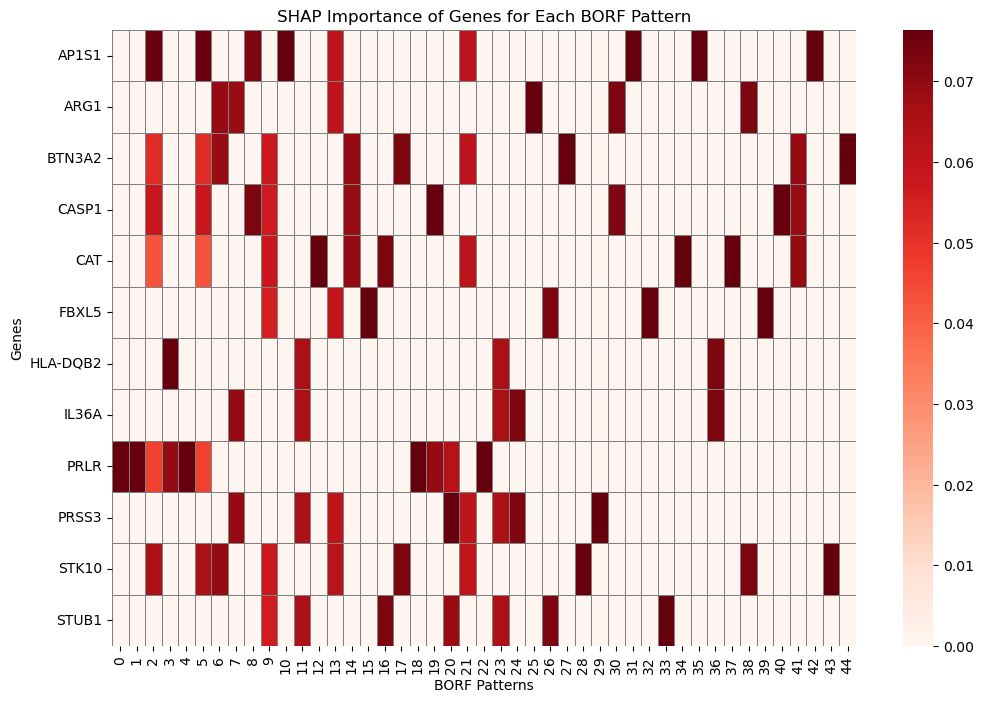

In [20]:
# heatmap of shap_df

import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(shap_df.apply(pd.to_numeric, errors='coerce'), cmap="Reds", linewidths=0.5, linecolor='gray')
plt.title("SHAP Importance of Genes for Each BORF Pattern")
plt.xlabel("BORF Patterns")
plt.ylabel("Genes")
plt.show()

In [21]:
shap_df.apply(pd.to_numeric, errors='coerce')

,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
AP1S1,0.000000,0.000000,0.075723,0.000000,0.000000,0.075723,0.000000,0.000000,0.072601,0.000000,...,0.076389,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076389,0.000000,0.000000
ARG1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.069024,0.068655,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.072601,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BTN3A2,0.000000,0.000000,0.051725,0.000000,0.000000,0.051725,0.068655,0.000000,0.000000,0.057049,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.069024,0.000000,0.000000,0.076389
CASP1,0.000000,0.000000,0.057833,0.000000,0.000000,0.057833,0.000000,0.000000,0.072917,0.056649,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.076389,0.068655,0.000000,0.000000,0.000000
CAT,0.000000,0.000000,0.042707,0.000000,0.000000,0.042707,0.000000,0.000000,0.000000,0.057644,...,0.000000,0.000000,0.076389,0.000000,0.000000,0.000000,0.069329,0.000000,0.000000,0.000000
FBXL5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.055490,...,0.000000,0.000000,0.000000,0.000000,0.076389,0.000000,0.000000,0.000000,0.000000,0.000000
HLA-DQB2,0.000000,0.000000,0.000000,0.076073,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.072601,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
IL36A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.069329,0.000000,0.000000,...,0.000000,0.072917,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PRLR,0.076389,0.076389,0.046785,0.069444,0.076389,0.046785,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PRSS3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.069024,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Edge weighting

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from statsmodels.stats.multitest import multipletests

# Parameters
beta = 0.1
min_cluster_size = 3
max_cluster_size = 30
n_perms = 1000
threshold_sweep = [50, 70, 80, 90, 95, 99]
jaccard_epsilon = 0.01 

### Build Network ###
G = nx.from_pandas_edgelist(ppi_synth, 'gene1', 'gene2')
nodes = list(G.nodes())
n_nodes = len(nodes)

print(f"PPI Graph: {n_nodes} nodes, {G.number_of_edges()} edges")

print("\nWeighting edges based on local topological density (Jaccard Similarity)...")
jaccard_preds = nx.jaccard_coefficient(G, G.edges())

for u, v, j_score in jaccard_preds:
    # Weight = Jaccard Score + small epsilon
    G[u][v]['density_weight'] = j_score + jaccard_epsilon

# Build the Weighted Adjacency Matrix (A)
A = nx.to_numpy_array(G, nodelist=nodes, weight='density_weight')

# Normalize columns to create the Transition Matrix (W)
col_sums = A.sum(axis=0)
col_sums[col_sums == 0] = 1 
W = A / col_sums

### Calculate Closed-Form Topological Matrix (P) ###
print("Calculating closed-form Similarity Matrix (P)...")
I = np.eye(n_nodes)
P = beta * np.linalg.inv(I - (1 - beta) * W)

significant_subnetworks = []

for idx in range(shap_df.shape[1]):
    pattern_name = f"PATTERN_{idx}"
    print(f"\n{'='*40}\n--- {pattern_name} ---\n{'='*40}")

    gene_scores = shap_df.iloc[:, idx].copy().abs() 
    gene_scores.index = gene_scores.index.astype(str)

    f = np.zeros(n_nodes)
    for i, node in enumerate(nodes):
        if str(node) in gene_scores.index:
            f[i] = gene_scores[str(node)]

    s_obs = np.dot(P, f)
    
    A_binary = nx.to_numpy_array(G, nodelist=nodes, weight=None) 
    S_edges_obs = A_binary * np.outer(s_obs, s_obs)
    positive_edges = S_edges_obs[S_edges_obs > 0]
    
    if len(positive_edges) == 0:
        continue

    # Propose Candidate Subnetworks
    candidate_clusters = set()
    
    for pct in threshold_sweep:
        delta = np.percentile(positive_edges, pct)
        S_sparse = np.where(S_edges_obs >= delta, S_edges_obs, 0)
        G_thresh = nx.from_numpy_array(S_sparse, create_using=nx.Graph)
        
        for comp in nx.connected_components(G_thresh):
            if min_cluster_size <= len(comp) <= max_cluster_size:
                candidate_clusters.add(tuple(sorted([nodes[i] for i in comp])))

    if not candidate_clusters:
        print("  No candidate clusters formed across any threshold scale.")
        continue

    print(f"  Generated {len(candidate_clusters)} unique candidate subnetworks across scales.")
    print("  Running vectorized permutation testing...")

    f_perms = np.column_stack([np.random.permutation(f) for _ in range(n_perms)])
    s_null_matrix = np.dot(P, f_perms)

    cluster_data = []
    p_values = []

    for comp in candidate_clusters:
        comp_indices = [nodes.index(g) for g in comp]
        
        obs_score = np.median(s_obs[comp_indices])
        null_scores = np.median(s_null_matrix[comp_indices, :], axis=0)
        
        beats_true = np.sum(null_scores >= obs_score)
        emp_p = (beats_true + 1) / (n_perms + 1)
        
        p_values.append(emp_p)
        cluster_data.append({
            'Size': len(comp),
            'Median_Score': obs_score,
            'Genes': comp
        })

    # FWER CORRECTION
    if correction_method == 'fdr':
      reject, q_values, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    if correction_method == 'bonferroni':
      reject, q_values, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

    passed_count = 0
    for i, cluster in enumerate(cluster_data):
        if reject[i]:
            passed_count += 1
            print(f"  ✅ Significant Subnetwork (Size {cluster['Size']}, Q-Val: {q_values[i]:.4f})")
            
            significant_subnetworks.append({
                'Pattern': pattern_name,
                'Size': cluster['Size'],
                'Median_Score': cluster['Median_Score'],
                'P_Value': p_values[i],
                'Q_Value_FWER': q_values[i],
                'Genes': ", ".join(cluster['Genes'])
            })
            
    if passed_count == 0:
        print("  ❌ No candidate subnetworks survived FWER correction.")

print("\n" + "="*70)
print("FINAL SIGNIFICANT SUBNETWORKS DATAFRAME (FWER CORRECTED)")
print("="*70)

if significant_subnetworks:
    final_results_df = pd.DataFrame(significant_subnetworks)
    final_results_df = final_results_df.sort_values(by=['Pattern', 'Q_Value_FWER'])
    print(final_results_df.to_string(index=False))
else:
    final_results_df = pd.DataFrame(columns=['Pattern', 'Size', 'Median_Score', 'P_Value', 'Q_Value_FWER', 'Genes'])
    print("No statistically significant subnetworks found across any pattern.")

final_results_df

PPI Graph: 1867 nodes, 23680 edges

Weighting edges based on local topological density (Jaccard Similarity)...
Calculating closed-form Similarity Matrix (P)...

--- PATTERN_0 ---
  No candidate clusters formed across any threshold scale.

--- PATTERN_1 ---
  No candidate clusters formed across any threshold scale.

--- PATTERN_2 ---
  Generated 1 unique candidate subnetworks across scales.
  Running vectorized permutation testing...
  ✅ Significant Subnetwork (Size 19, Q-Val: 0.0050)

--- PATTERN_3 ---
  No candidate clusters formed across any threshold scale.

--- PATTERN_4 ---
  No candidate clusters formed across any threshold scale.

--- PATTERN_5 ---
  Generated 1 unique candidate subnetworks across scales.
  Running vectorized permutation testing...
  ✅ Significant Subnetwork (Size 19, Q-Val: 0.0070)

--- PATTERN_6 ---
  No candidate clusters formed across any threshold scale.

--- PATTERN_7 ---
  No candidate clusters formed across any threshold scale.

--- PATTERN_8 ---
  No ca

,Pattern,Size,Median_Score,P_Value,Q_Value_FWER,Genes
2,PATTERN_13,14,0.001208,0.041958,0.041958,"APP, DEFA5, DEFA6, DEFB1, DEFB103A, DEFB104A, ..."
0,PATTERN_2,19,0.002832,0.004995,0.004995,"AP1B1, AP1G1, AP1M1, AP1M2, AP1S1, AP1S2, AP1S..."
3,PATTERN_21,20,0.002275,0.021978,0.021978,"AP1B1, AP1G1, AP1M1, AP1M2, AP1S1, AP1S2, AP1S..."
1,PATTERN_5,19,0.002832,0.006993,0.006993,"AP1B1, AP1G1, AP1M1, AP1M2, AP1S1, AP1S2, AP1S..."


In [ ]:
def resolve_overlapping_subnetworks(df, overlap_thresh=0.7, strategy='largest'):
    """
    Removes redundant subnetworks based on the Overlap Coefficient.
    Overlap Coef = len(A intersection B) / min(len(A), len(B))
    """
    if df.empty:
        return df
        
    resolved_rows = []
    
    for pattern, group in df.groupby('Pattern'):
        if strategy == 'largest':
            group = group.sort_values(by=['Size', 'Q_Value_FWER'], ascending=[False, True])
        elif strategy == 'significant':
            group = group.sort_values(by=['Q_Value_FWER', 'Size'], ascending=[True, False])
            
        accepted_clusters = []
        
        for _, row in group.iterrows():
            current_genes = set(row['Genes'].split(', '))
            is_redundant = False
            
            # Check overlap
            for accepted_row in accepted_clusters:
                accepted_genes = set(accepted_row['Genes'].split(', '))
                
                # Overlap Coefficient
                intersection = len(current_genes.intersection(accepted_genes))
                min_size = min(len(current_genes), len(accepted_genes))
                
                overlap_coef = intersection / min_size
                
                if overlap_coef >= overlap_thresh:
                    is_redundant = True
                    break
            
            if not is_redundant:
                accepted_clusters.append(row)
                
        resolved_rows.extend(accepted_clusters)
        
    return pd.DataFrame(resolved_rows)

print("\n" + "="*70)
print("FILTERED & NON-REDUNDANT SUBNETWORKS")
print("="*70)

filtered_results_df = resolve_overlapping_subnetworks(
    final_results_df, 
    overlap_thresh=0.1, 
    strategy='significant' 
)

print(filtered_results_df.to_string(index=False))


FILTERED & NON-REDUNDANT SUBNETWORKS
   Pattern  Size  Median_Score  P_Value  Q_Value_FWER                                                                                                                                 Genes
PATTERN_13    14      0.001208 0.041958      0.041958                      APP, DEFA5, DEFA6, DEFB1, DEFB103A, DEFB104A, DEFB105A, DEFB106B, DEFB107A, DEFB4A, MBL2, PRSS2, PRSS3, SERPINA1
 PATTERN_2    19      0.002832 0.004995      0.004995        AP1B1, AP1G1, AP1M1, AP1M2, AP1S1, AP1S2, AP1S3, AP2A1, AP2A2, AP2B1, AP2M1, AP2S1, ARF1, CLTA, CLTC, DNM1, DNM2, VAMP2, VAMP8
PATTERN_21    20      0.002275 0.021978      0.021978 AP1B1, AP1G1, AP1M1, AP1M2, AP1S1, AP1S2, AP1S3, AP2A1, AP2A2, AP2B1, AP2M1, AP2S1, ARF1, CLTA, CLTC, DNM1, DNM2, VAMP2, VAMP7, VAMP8
 PATTERN_5    19      0.002832 0.006993      0.006993        AP1B1, AP1G1, AP1M1, AP1M2, AP1S1, AP1S2, AP1S3, AP2A1, AP2A2, AP2B1, AP2M1, AP2S1, ARF1, CLTA, CLTC, DNM1, DNM2, VAMP2, VAMP8


## Celltype specificity filter

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

def resolve_overlapping_subnetworks(df, overlap_thresh=0.7, strategy='optimal_core'):
    """Removes redundant subnetworks based on the Overlap Coefficient."""
    if df.empty: return df
    resolved_rows = []
    
    for pattern, group in df.groupby('Pattern'):
        if strategy == 'largest':
            group = group.sort_values(by=['Size', 'Q_Value_FWER'], ascending=[False, True])
        elif strategy == 'significant':
            group = group.sort_values(by=['Q_Value_FWER', 'Size'], ascending=[True, False])
        elif strategy == 'optimal_core':
            # NEW: Prioritizes the lowest Q-value. If tied, heavily penalizes 
            # size by picking the smallest, tightest core.
            group = group.sort_values(by=['Q_Value_FWER', 'Size'], ascending=[True, True])
            
        accepted_clusters = []
        for _, row in group.iterrows():
            current_genes = set(row['Genes'].split(', '))
            is_redundant = False
            
            for accepted_row in accepted_clusters:
                accepted_genes = set(accepted_row['Genes'].split(', '))
                intersection = len(current_genes.intersection(accepted_genes))
                min_size = min(len(current_genes), len(accepted_genes))
                
                if (intersection / min_size) >= overlap_thresh:
                    is_redundant = True
                    break
            
            if not is_redundant:
                accepted_clusters.append(row)
        resolved_rows.extend(accepted_clusters)
        
    return pd.DataFrame(resolved_rows)


def filter_by_cell_specificity(resolved_df, cell_expr_df, cell_metadata, target_cell_type, p_val_thresh=0.05, min_fc=1.2):
    """Filters discovered subnetworks based on their expression specificity to a target cell type."""
    if resolved_df.empty: return resolved_df
    specific_subnetworks = []
    
    aligned_cells = cell_expr_df.index.intersection(cell_metadata.index)
    cell_expr_df = cell_expr_df.loc[aligned_cells]
    cell_metadata = cell_metadata.loc[aligned_cells]
    
    target_mask = (cell_metadata == target_cell_type)
    bg_mask = ~target_mask
    print(f"Testing specificity for '{target_cell_type}': {target_mask.sum()} target cells vs {bg_mask.sum()} background cells.")

    for _, row in resolved_df.iterrows():
        subnetwork_genes = row['Genes'].split(', ')
        valid_genes = [g for g in subnetwork_genes if g in cell_expr_df.columns]
        
        if not valid_genes: continue
            
        # Subnetwork Activity Score per cell
        cell_activity_scores = cell_expr_df[valid_genes].mean(axis=1)
        
        target_scores = cell_activity_scores[target_mask]
        bg_scores = cell_activity_scores[bg_mask]
        
        target_mean = target_scores.mean()
        bg_mean = bg_scores.mean()
        fold_change = (target_mean + 1e-9) / (bg_mean + 1e-9)
        
        # Bypass p-value requirement if there are too few replicates to calculate it
        if len(target_scores) < 3 or len(bg_scores) < 3:
            p_val = 0.0
        else:
            try:
                stat, p_val = mannwhitneyu(target_scores, bg_scores, alternative='greater')
            except ValueError:
                p_val = 1.0 
            
        if p_val <= p_val_thresh and fold_change >= min_fc:
            row_dict = row.to_dict()
            row_dict['Target_Mean'] = round(target_mean, 4)
            row_dict['Background_Mean'] = round(bg_mean, 4)
            row_dict['Fold_Change'] = round(fold_change, 3)
            row_dict['Specificity_P_Val'] = p_val
            specific_subnetworks.append(row_dict)
            
    final_specific_df = pd.DataFrame(specific_subnetworks)
    if not final_specific_df.empty:
        # Sort by Fold Change to prioritize the most highly specific subnetworks
        final_specific_df = final_specific_df.sort_values(by='Fold_Change', ascending=False)
        
    return final_specific_df

filtered_results_df = resolve_overlapping_subnetworks(
    final_results_df, 
    overlap_thresh=0.5,
    strategy='largest' 
)

# Average expression across timepoints to get a scalar value per gene per cell
mean_expr = df_synth.mean(axis=1)
df_temp = pd.DataFrame({'expr': mean_expr})
df_temp['Gene'] = df_temp.index.get_level_values("gene")
df_temp['Cell'] = df_temp.index.get_level_values("celltype") + '_' + df_temp.index.get_level_values("patient")
df_temp['CellType'] = df_temp.index.get_level_values("celltype")

cell_expr_matrix = df_temp.pivot(index='Cell', columns='Gene', values='expr')
cell_types_series = df_temp.drop_duplicates('Cell').set_index('Cell')['CellType']

print("\n" + "="*70)
print("FINAL REFINED & CELL-TYPE SPECIFIC SUBNETWORKS")
print("="*70)

cell_specific_df = filter_by_cell_specificity(
    resolved_df=filtered_results_df, 
    cell_expr_df=cell_expr_matrix, 
    cell_metadata=cell_types_series, 
    target_cell_type=target_ct,
    p_val_thresh=0.05,
    min_fc=1.2
)

if not cell_specific_df.empty:
    cols = ['Pattern', 'Size', 'Q_Value_FWER', 'Target_Mean', 'Background_Mean', 'Fold_Change', 'Genes']
    print(cell_specific_df[cols].to_string(index=False))
else:
    print("No subnetworks passed the cell-type specificity filter.")


FINAL REFINED & CELL-TYPE SPECIFIC SUBNETWORKS
Testing specificity for 'CD4memoryactivatedT': 5 target cells vs 133 background cells.
No subnetworks passed the cell-type specificity filter.


In [25]:
cell_specific_df
# sort by Fold Change to prioritize the most specific modules
if not cell_specific_df.empty:
    cell_specific_df = cell_specific_df.sort_values(by='Q_Value_FWER', ascending=True)
    print(cell_specific_df.to_string(index=False))

In [44]:
cell_specific_df = cell_specific_df.reset_index()
cell_specific_df.to_csv(f"{target_ct}_significant_subnetworks_{correction_method}.csv", index=True)

/home/a.collesei/software/miniforge3/envs/SHISMA_env/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/a.collesei/software/miniforge3/envs/SHISMA_env/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/a.collesei/software/miniforge3/envs/SHISMA_env/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current 


--- Processing Row/Subnetwork 2 ---
Genes: ['APP', 'DEFA5', 'DEFA6', 'DEFB1', 'DEFB103A', 'DEFB104A', 'DEFB105A', 'DEFB106B', 'DEFB107A', 'DEFB4A', 'MBL2', 'PRSS2', 'PRSS3', 'SERPINA1']
Saved plot to: plots/CD4memoryactivatedT/Subnetwork_2_Pattern_13.png


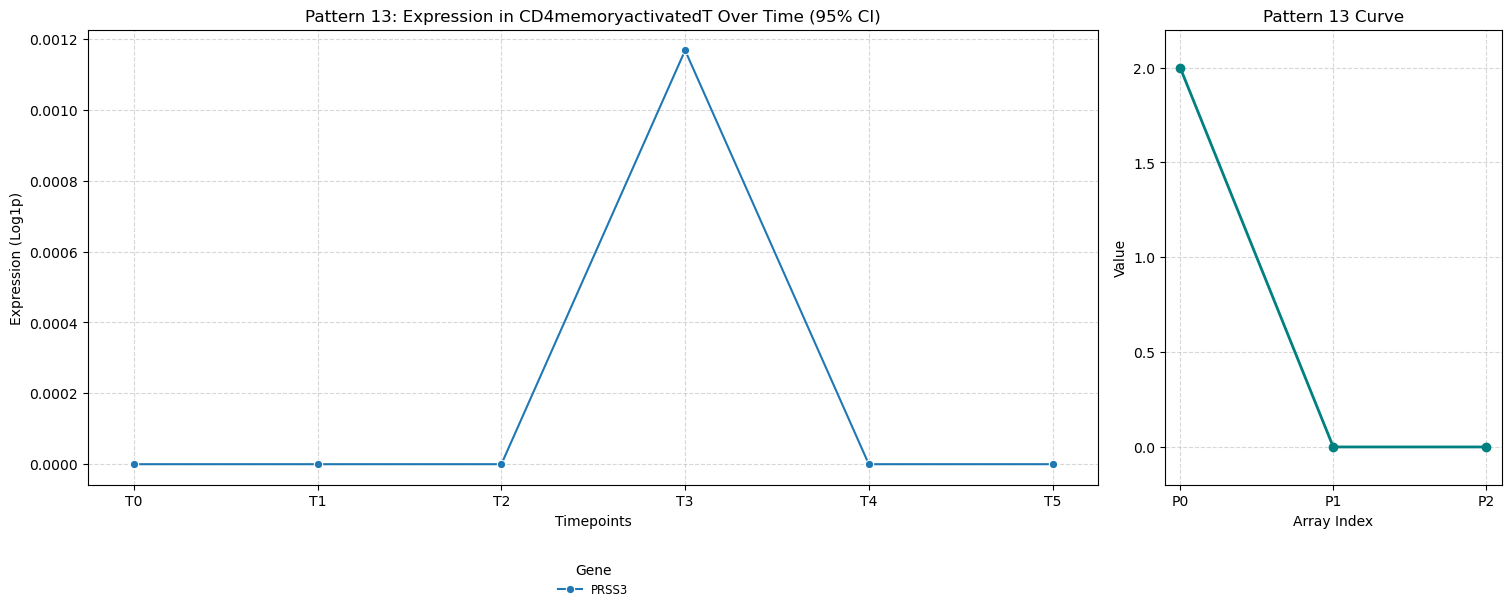


--- Processing Row/Subnetwork 0 ---
Genes: ['AP1B1', 'AP1G1', 'AP1M1', 'AP1M2', 'AP1S1', 'AP1S2', 'AP1S3', 'AP2A1', 'AP2A2', 'AP2B1', 'AP2M1', 'AP2S1', 'ARF1', 'CLTA', 'CLTC', 'DNM1', 'DNM2', 'VAMP2', 'VAMP8']
Saved plot to: plots/CD4memoryactivatedT/Subnetwork_0_Pattern_2.png


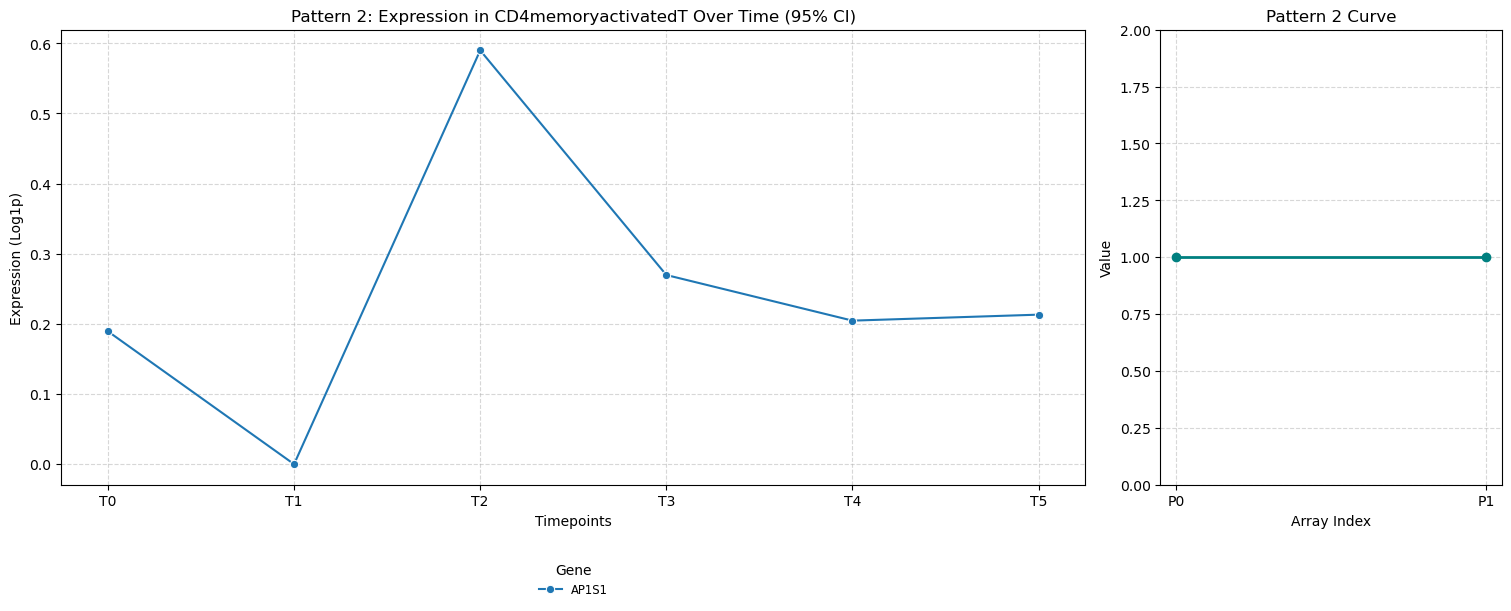


--- Processing Row/Subnetwork 3 ---
Genes: ['AP1B1', 'AP1G1', 'AP1M1', 'AP1M2', 'AP1S1', 'AP1S2', 'AP1S3', 'AP2A1', 'AP2A2', 'AP2B1', 'AP2M1', 'AP2S1', 'ARF1', 'CLTA', 'CLTC', 'DNM1', 'DNM2', 'VAMP2', 'VAMP7', 'VAMP8']
Saved plot to: plots/CD4memoryactivatedT/Subnetwork_3_Pattern_21.png


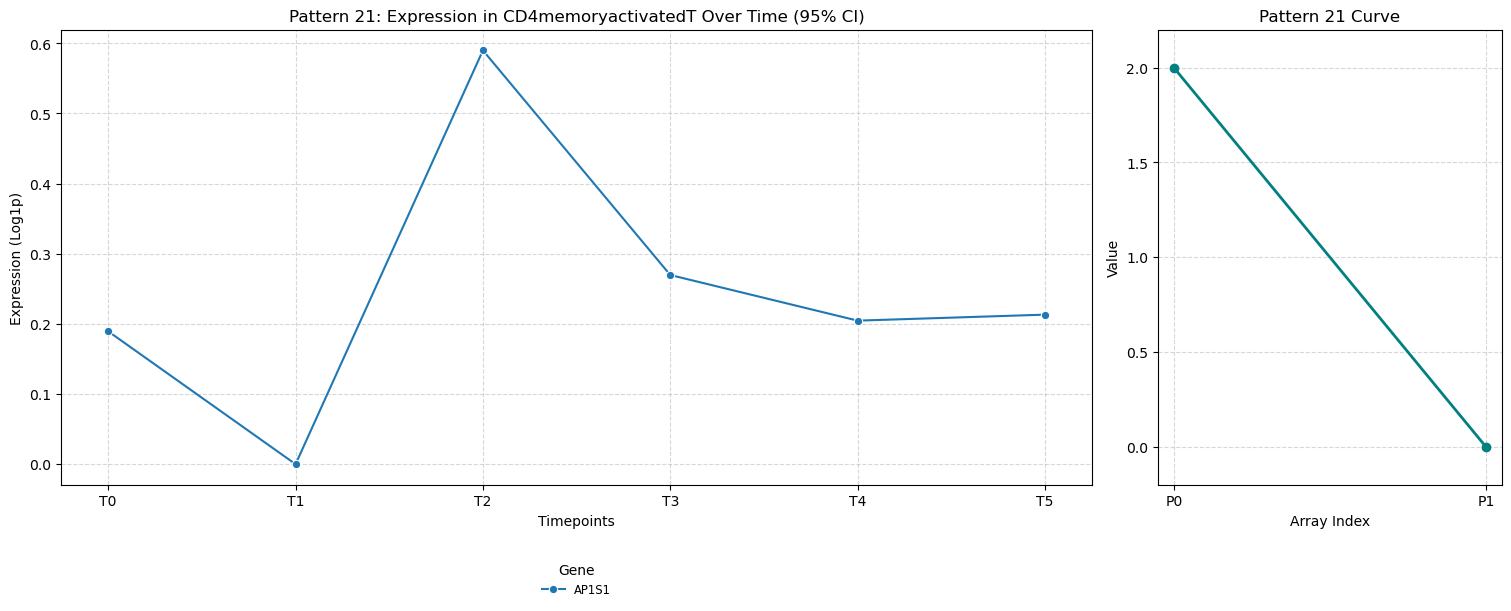


--- Processing Row/Subnetwork 1 ---
Genes: ['AP1B1', 'AP1G1', 'AP1M1', 'AP1M2', 'AP1S1', 'AP1S2', 'AP1S3', 'AP2A1', 'AP2A2', 'AP2B1', 'AP2M1', 'AP2S1', 'ARF1', 'CLTA', 'CLTC', 'DNM1', 'DNM2', 'VAMP2', 'VAMP8']
Saved plot to: plots/CD4memoryactivatedT/Subnetwork_1_Pattern_5.png


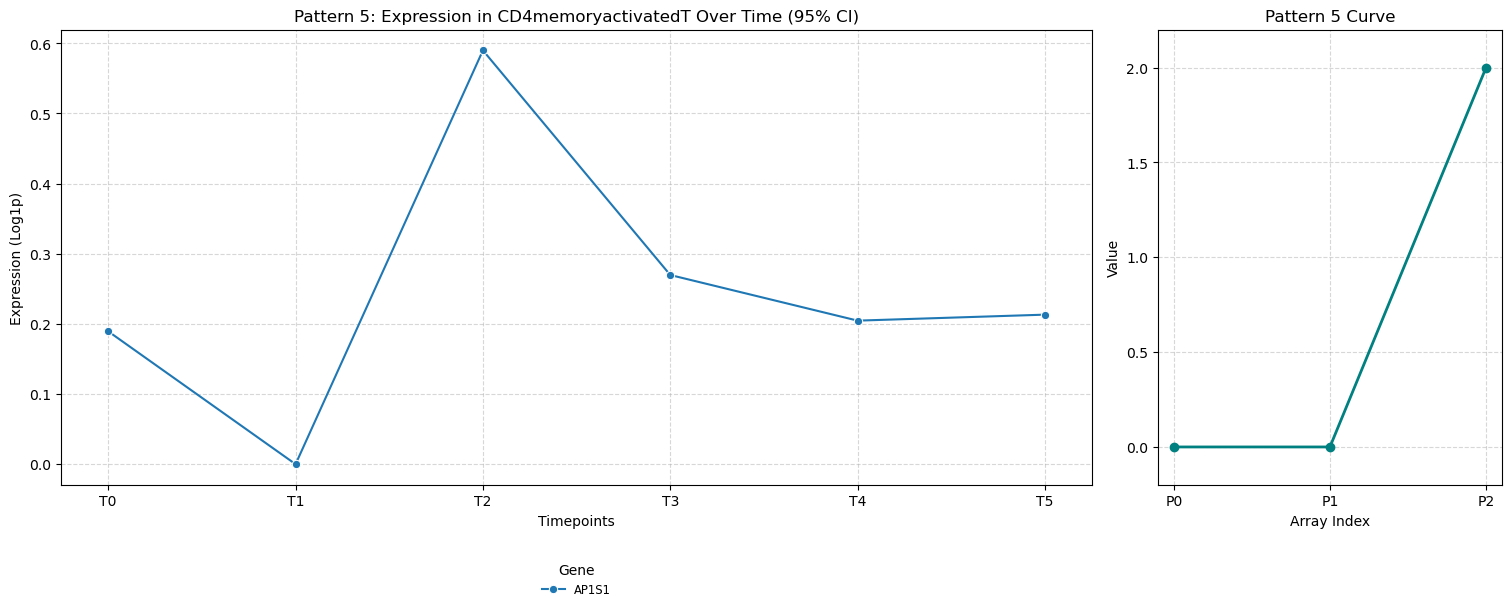

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

output_dir = f"plots/{target_ct}"
os.makedirs(output_dir, exist_ok=True)

# Export mappings
mapper = BagOfReceptiveFields(borf_model)
mapper.build(X_raw)

# Check if the dataframe is empty first
if not filtered_results_df.empty:

    for index, row in filtered_results_df.iterrows():

        top_subnetwork_genes = [g.strip() for g in row["Genes"].split(",")]
        print(f"\n--- Processing Row/Subnetwork {index} ---")
        print(f"Genes: {top_subnetwork_genes}")

        match = re.search(r"\d+", str(row["Pattern"]))
        if match:
            pattern_id = int(match.group())
        else:
            print(f"Skipping: Could not parse pattern ID from Pattern column value '{row.get('Pattern', 'Missing')}'")
            continue
        
        gene_level_values = df_target_ct.index.get_level_values("gene")
        genes_in_data = [
            g for g in top_subnetwork_genes if g in gene_level_values
        ]

        if genes_in_data:
            df_filtered = df_target_ct[gene_level_values.isin(genes_in_data)]

            df_reset = df_filtered.reset_index(level="gene")

          
            time_cols = [c for c in df_reset.columns if c != "gene"]

            df_long = df_reset.melt(
                id_vars=["gene"],
                value_vars=time_cols,
                var_name="Timepoints",
                value_name="Expression",
            )

          
            fig, (ax1, ax2) = plt.subplots(
                1,
                2,
                figsize=(15, 6),
                gridspec_kw={"width_ratios": [3, 1]},
                constrained_layout=True,
            )

          
            sns.lineplot(
                data=df_long,
                x="Timepoints",
                y="Expression",
                hue="gene",
                marker="o",
                errorbar=("ci", 95), 
                ax=ax1,
            )

          
            ax1.set_title(
                f"Pattern {pattern_id}: Expression in {target_ct} Over Time (95% CI)"
            )
            ax1.set_xlabel("Timepoints")
            ax1.set_ylabel("Expression (Log1p)")
            
          
            col_count = min(6, len(genes_in_data))
            
          
            ax1.legend(
                loc="upper center", 
                bbox_to_anchor=(0.5, -0.15), 
                title="Gene",
                ncol=col_count,
                fontsize="small",
                frameon=False 
            )
            ax1.grid(True, linestyle="--", alpha=0.5)

          
            try:
              
                word_arr = mapper[pattern_id].word_array
                x_positions = range(len(word_arr))

              
                ax2.plot(
                    x_positions, 
                    word_arr, 
                    marker='o', 
                    linestyle='-', 
                    color='teal', 
                    linewidth=2, 
                    markersize=6
                )
                
                ax2.set_title(f"Pattern {pattern_id} Curve")
                ax2.set_xlabel("Array Index")
                ax2.set_ylabel("Value")
                
              
                ax2.set_xticks(x_positions)
                ax2.set_xticklabels([f"P{k}" for k in x_positions])
                
              
                y_min, y_max = min(word_arr), max(word_arr)
                if y_min == y_max:
                    ax2.set_ylim(y_min - 1, y_max + 1)
                else:
                    padding = (y_max - y_min) * 0.1
                    ax2.set_ylim(y_min - padding, y_max + padding)
                
                ax2.grid(True, linestyle="--", alpha=0.5)

            except Exception as e:
                ax2.text(
                    0.5,
                    0.5,
                    f"Error loading mapper[{pattern_id}]:\n{str(e)}",
                    ha="center",
                    va="center",
                )
                ax2.axis("off")

          
          
            filename = os.path.join(output_dir, f"Subnetwork_{index}_Pattern_{pattern_id}.png")
            
          
            plt.savefig(filename, dpi=300, bbox_inches="tight")
            print(f"Saved plot to: {filename}")

          
            plt.show()

        else:
            print(
                f"Skipping plot: None of the genes for Subnetwork {index} were found in the expression data."
            )
else:
    print("The filtered_results_df is empty. No subnetworks to plot.")